<a href="https://colab.research.google.com/github/Sayandt-web/Deep-Learning-Approach-for-the-Detection-of-Noise-Type-in-Ancient-Images-/blob/main/Deep_Learning_Approach_for_the_Detection_of_Noise_Type_in_Ancient_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Approach for the Detection of Noise Type in Ancient Images ( Poonam Pawar)

https://www.mdpi.com/2071-1050/14/18/11786

In [ ]:
import os
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])

/content
/content/.config
Files: ['gce', '.last_update_check.json', 'default_configs.db', 'active_config', '.last_opt_in_prompt.yaml']
/content/.config/configurations
Files: ['config_default']
/content/.config/logs
/content/.config/logs/2026.06.04
Files: ['13.32.38.346437.log', '13.32.02.654775.log', '13.32.18.735754.log', '13.32.39.344962.log', '13.31.42.499627.log']
/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
Files: ['CODING DECODING practise set_copy.pdf', 'NPTEL.pdf', 'Untitled presentation.gslides', 'Online registration form uem.pdf', 'ISP 44 - joining letter.pdf']
/content/drive/MyDrive/Classroom
/content/drive/MyDrive/Classroom/B.Tech. 1st year(2024-2025) Batch A
/content/drive/MyDrive/Classroom/B.Tech 1st Semester A
Files: ['IMG_20240723_203203 (2).pdf', 'IMG_20240723_203203 (1).pdf', 'IMG_20240723_203203.pdf']
/content/drive/MyDrive/Classroom/SECTION A 2024-25
Files: ['0db46487-8499-401d-a672-ca76a3dd236c.pdf']
/content/drive/MyDrive/Classroom/

Total Images Found: 263
Image Path: /content/drive/MyDrive/1/0010089264bb0573.jpg
Shape: (800, 699)


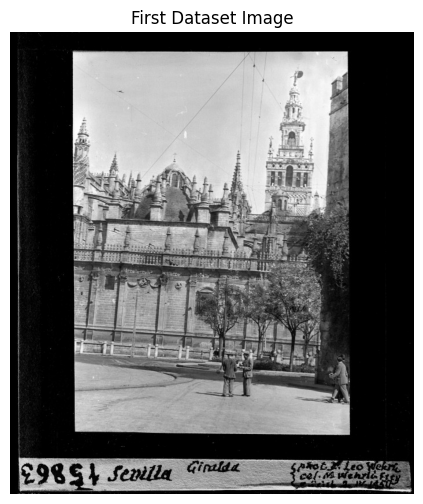

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt

# Dataset folder
dataset_path = "/content/drive/MyDrive/1"

# Collect all image files
image_files = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
    image_files.extend(
        glob.glob(f"{dataset_path}/**/{ext}", recursive=True)
    )

print("Total Images Found:", len(image_files))

if len(image_files) == 0:
    print("No images found!")
else:
    # Load first image
    img = cv2.imread(image_files[0], cv2.IMREAD_GRAYSCALE)

    print("Image Path:", image_files[0])
    print("Shape:", img.shape)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title("First Dataset Image")
    plt.axis('off')
    plt.show()

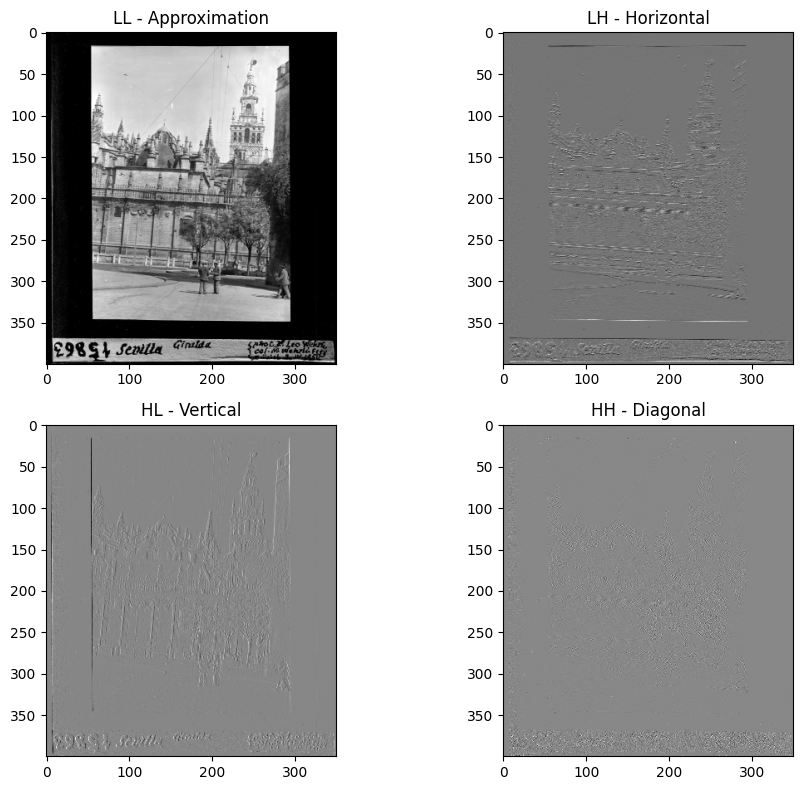

In [ ]:
import pywt
import matplotlib.pyplot as plt

coeffs = pywt.dwt2(img, 'haar')
LL, (LH, HL, HH) = coeffs

plt.figure(figsize=(10,8))

plt.subplot(221)
plt.imshow(LL, cmap='gray')
plt.title("LL - Approximation")

plt.subplot(222)
plt.imshow(LH, cmap='gray')
plt.title("LH - Horizontal")

plt.subplot(223)
plt.imshow(HL, cmap='gray')
plt.title("HL - Vertical")

plt.subplot(224)
plt.imshow(HH, cmap='gray')
plt.title("HH - Diagonal")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

patch_size = 32

patches = []
labels = []

# Estimate noise level
noise_sigma = np.median(np.abs(HH)) / 0.6745

for i in range(0, HH.shape[0] - patch_size, patch_size):

    for j in range(0, HH.shape[1] - patch_size, patch_size):

        patch = HH[i:i+patch_size,
                   j:j+patch_size]

        patches.append(patch)

        # Simple noise labeling
        if np.std(patch) > noise_sigma:
            labels.append(1)   # Noisy
        else:
            labels.append(0)   # Clean

patches = np.array(patches)
labels = np.array(labels)

print("Total Patches:", len(patches))
print("Patch Shape:", patches[0].shape)

Total Patches: 120
Patch Shape: (32, 32)


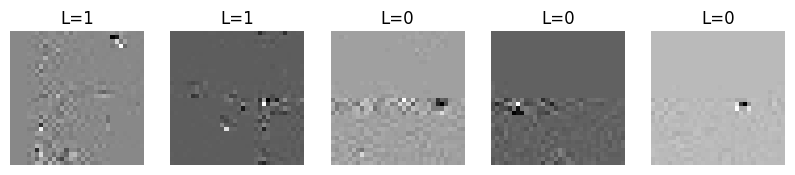

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(min(5, len(patches))):

    plt.subplot(1,5,i+1)

    plt.imshow(patches[i], cmap='gray')

    plt.title(f"L={labels[i]}")

    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

# Convert to NumPy arrays
patches = np.array(patches, dtype=np.float32)
labels = np.array(labels)

# Normalize pixel values
patches = (patches - patches.min()) / (patches.max() - patches.min() + 1e-8)

# Reshape for CNN
patches = patches.reshape(
    patches.shape[0],
    patches.shape[1],
    patches.shape[2],
    1
)

print("Patch Shape:", patches.shape)

# Convert labels to categorical
labels = to_categorical(labels, num_classes=2)

print("Label Shape:", labels.shape)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    patches,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

Patch Shape: (120, 32, 32, 1)
Label Shape: (120, 2)

Training Samples: 96
Testing Samples : 24

X_train Shape: (96, 32, 32, 1)
X_test Shape : (24, 32, 32, 1)


In [ ]:
print("Noisy Patches :", np.sum(np.argmax(labels, axis=1) == 1))
print("Clean Patches :", np.sum(np.argmax(labels, axis=1) == 0))

Noisy Patches : 104
Clean Patches : 16


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# CNN Model
model = Sequential()

# Convolution Block 1
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,1)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 2
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 3
model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(2, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,266 (2.48 MB)

 Trainable params: 650,818 (2.48 MB)

 Non-trainable params: 448 (1.75 KB)

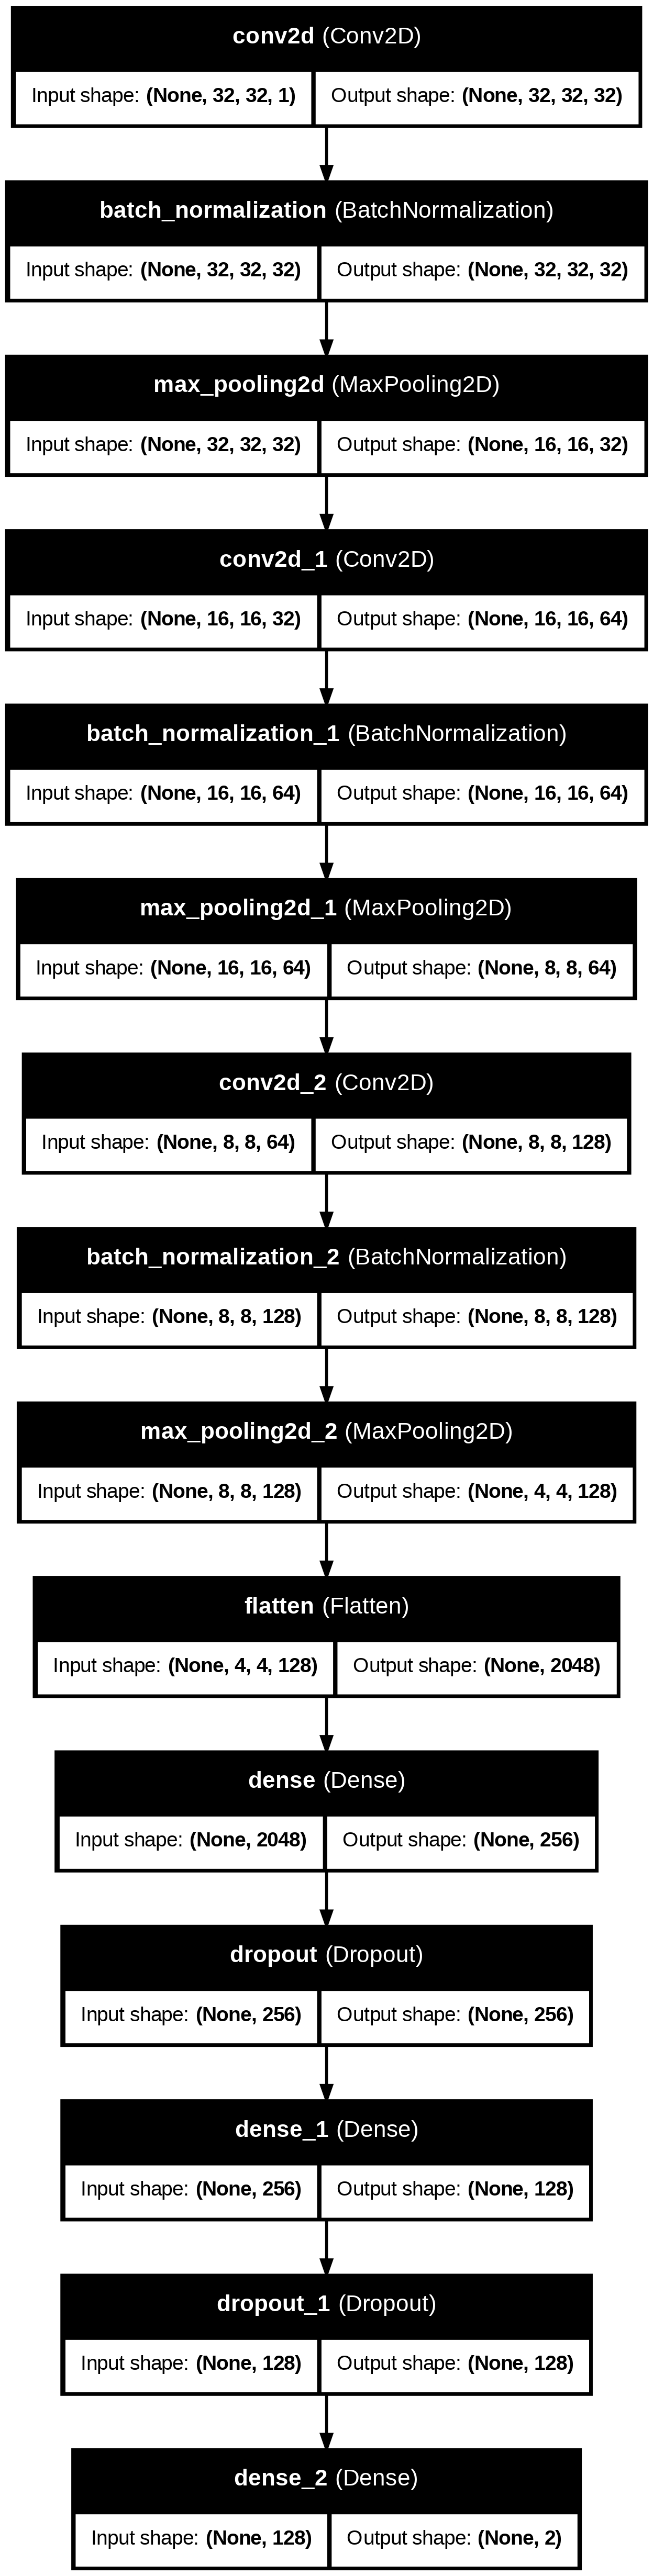

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

In [ ]:
!apt-get install graphviz -y
!pip install pydot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 428ms/step - accuracy: 0.6458 - loss: 2.3975 - val_accuracy: 0.8750 - val_loss: 0.6437
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.8750 - loss: 0.4722 - val_accuracy: 0.8750 - val_loss: 0.6767
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.8021 - loss: 0.5073 - val_accuracy: 0.1667 - val_loss: 0.7131
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.8646 - loss: 0.3498 - val_accuracy: 0.1250 - val_loss: 0.7492
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8646 - loss: 0.2946 - val_accuracy: 0.1250 - val_loss: 0.7838
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.8542 - loss: 0.3688 - val_accuracy: 0.1250 - val_loss: 0.8237
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.8125 - loss: 0.4559 - val_accuracy: 0.1250 - val_loss: 0.8660
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9167 - loss: 0.2119 - val_accuracy: 0.1250 - val_loss:

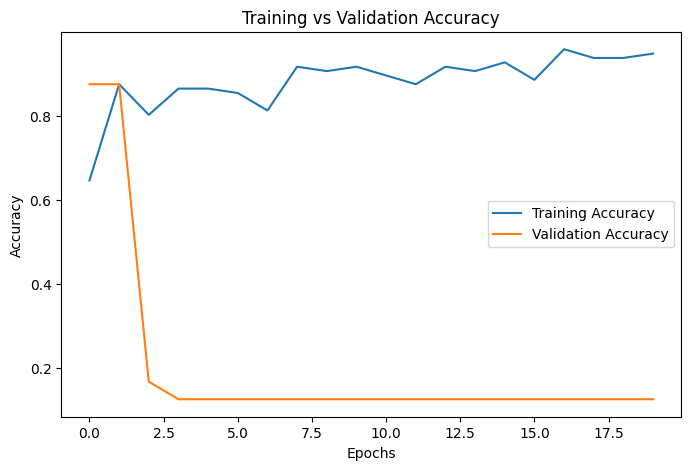

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

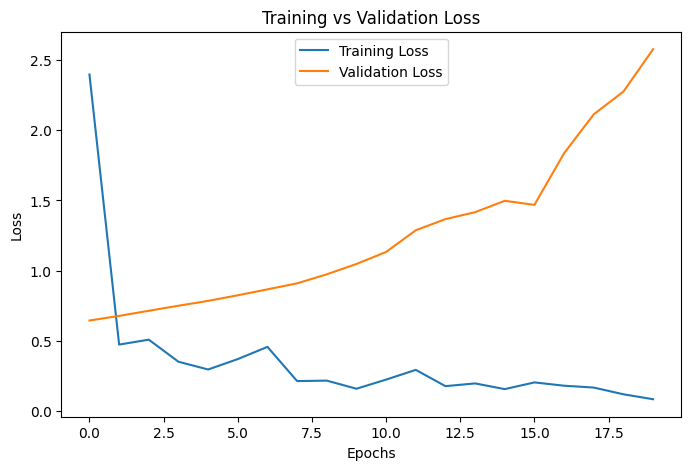

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1250 - loss: 2.5779
Test Loss: 2.5778872966766357
Test Accuracy: 0.125


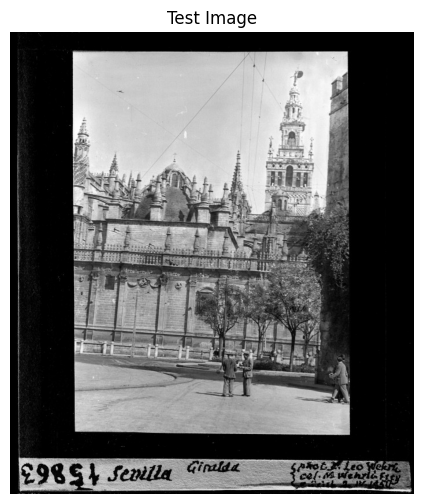

In [ ]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

test_image_path = image_files[0]  # Use any image

img = cv2.imread(
    test_image_path,
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title("Test Image")
plt.axis('off')
plt.show()

In [ ]:
coeffs = pywt.dwt2(img, 'haar')

LL, (LH, HL, HH) = coeffs

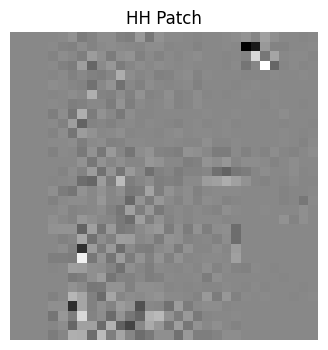

In [ ]:
patch = HH[0:32, 0:32]

plt.figure(figsize=(4,4))
plt.imshow(patch, cmap='gray')
plt.title("HH Patch")
plt.axis('off')
plt.show()

In [ ]:
patch = patch.astype(np.float32)

patch = (patch - patch.min()) / (
    patch.max() - patch.min() + 1e-8
)

patch = patch.reshape(
    1,
    32,
    32,
    1
)

In [ ]:
prediction = model.predict(patch)

print("Prediction Probabilities:")
print(prediction)

predicted_class = np.argmax(prediction)

if predicted_class == 1:
    print("Result: Noisy Patch Detected")
else:
    print("Result: Clean Patch")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Prediction Probabilities:
[[0.94534427 0.05465576]]
Result: Clean Patch


In [ ]:
patch_size = 32

noise_count = 0
clean_count = 0

for i in range(
        0,
        HH.shape[0] - patch_size,
        patch_size):

    for j in range(
            0,
            HH.shape[1] - patch_size,
            patch_size):

        patch = HH[
            i:i+patch_size,
            j:j+patch_size
        ]

        patch = patch.astype(np.float32)

        patch = (
            patch - patch.min()
        ) / (
            patch.max() -
            patch.min() +
            1e-8
        )

        patch = patch.reshape(
            1,
            32,
            32,
            1
        )

        pred = model.predict(
            patch,
            verbose=0
        )

        label = np.argmax(pred)

        if label == 1:
            noise_count += 1
        else:
            clean_count += 1

print("Noisy Patches:", noise_count)
print("Clean Patches:", clean_count)

Noisy Patches: 0
Clean Patches: 120


In [ ]:
model.save(
    "/content/dwt_cnn_noise_detector.h5"
)

print("Model Saved Successfully")

Model Saved Successfully
